In [1]:

# ============================================================
# TASK 3 — SETUP
# ============================================================

import os
import gc
import json
import time
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from scipy.stats import wilcoxon

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Locked Task 2 input protocol
IMG_HEIGHT = 224
IMG_WIDTH = 224
CHANNELS = 3
IMAGE_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

MAX_EPOCHS = 25
INITIAL_LR = 1e-3
EARLY_STOPPING_PATIENCE = 5
LR_PATIENCE = 2
LR_REDUCTION_FACTOR = 0.5
MIN_LR = 1e-6
PRIMARY_METRIC = "macro_f1"

# ------------------------------------------------------------
# Runtime switches
#
# Set a switch to False if you want to run the notebook in
# stages on Kaggle instead of doing the whole study at once.
# ------------------------------------------------------------

RUN_TUNING_EXPERIMENTS = True
RUN_CV = True
RUN_FINAL_TEST = True
RUN_EXPLAINABILITY = True

# The full ablation set is deliberately controlled rather than
# randomly searching many configurations.
EXPERIMENT_EPOCH_CAP = 25
CV_EPOCH_CAP = 20

OUTPUT_DIR = Path("/kaggle/working/task3_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

KAGGLE_INPUT = Path("/kaggle/input")

print("=" * 88)
print("TRACK 3 — TASK 3")
print("=" * 88)
print("TensorFlow:", tf.__version__)
print("GPU(s):", tf.config.list_physical_devices("GPU"))
print("Output:", OUTPUT_DIR)


TRACK 3 — TASK 3
TensorFlow: 2.20.0
GPU(s): [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Output: /kaggle/working/task3_outputs


In [2]:

# ============================================================
# LOAD LOCKED TASK 2 ARTIFACTS
# ============================================================

def find_required_file(filename):
    matches = list(KAGGLE_INPUT.rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f"Could not find {filename}. "
            "Attach the Task 2 output dataset to this notebook."
        )
    if len(matches) > 1:
        print(f"WARNING: multiple copies of {filename}; using:")
        print(matches[0])
    return matches[0]

TRAIN_CSV = find_required_file("FINAL_train_split.csv")
VAL_CSV = find_required_file("FINAL_validation_split.csv")
TEST_CSV = find_required_file("FINAL_test_split.csv")
CLASS_MAPPING_JSON = find_required_file("final_class_mapping.json")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

with open(CLASS_MAPPING_JSON, "r") as f:
    raw_mapping = json.load(f)

class_mapping = {int(k): v for k, v in raw_mapping.items()}
class_names = [class_mapping[i] for i in sorted(class_mapping)]
NUM_CLASSES = len(class_names)

assert NUM_CLASSES == 24
assert set(train_df["label"].unique()) == set(range(NUM_CLASSES))
assert set(val_df["label"].unique()) == set(range(NUM_CLASSES))
assert set(test_df["label"].unique()) == set(range(NUM_CLASSES))

# Exact-content leakage gate
for a, b, an, bn in [
    (train_df, val_df, "train", "validation"),
    (train_df, test_df, "train", "test"),
    (val_df, test_df, "validation", "test"),
]:
    if "pixel_hash" in a.columns and "pixel_hash" in b.columns:
        overlap = set(a.pixel_hash) & set(b.pixel_hash)
        assert len(overlap) == 0, f"{an}/{bn} content leakage detected."

print("Locked split:")
print(f"  train      : {len(train_df):,}")
print(f"  validation : {len(val_df):,}")
print(f"  test       : {len(test_df):,}")
print(f"  classes    : {NUM_CLASSES}")
print("✓ Locked Task 2 partitions loaded.")


Locked split:
  train      : 5,612
  validation : 1,203
  test       : 1,203
  classes    : 24
✓ Locked Task 2 partitions loaded.


In [3]:

# ============================================================
# INPUT PIPELINE + AUGMENTATION
# ============================================================

def load_image(filepath, label):
    image_bytes = tf.io.read_file(filepath)
    image = tf.io.decode_image(
        image_bytes, channels=1, expand_animations=False
    )
    image.set_shape([None, None, 1])
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, IMAGE_SIZE, method="bilinear")
    image = image / 255.0
    image = tf.image.grayscale_to_rgb(image)
    image.set_shape([IMG_HEIGHT, IMG_WIDTH, CHANNELS])
    return image, tf.cast(label, tf.int32)

def create_tf_dataset(dataframe, training=False, batch_size=BATCH_SIZE):
    ds = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].astype(str).values,
        dataframe["label"].astype(np.int32).values
    ))
    if training:
        ds = ds.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

def create_augmentation(enabled=True):
    if not enabled:
        return tf.keras.layers.Lambda(lambda x: x, name="no_augmentation")
    return tf.keras.Sequential([
        tf.keras.layers.RandomTranslation(
            height_factor=0.02, width_factor=0.02,
            fill_mode="reflect", seed=SEED
        ),
        tf.keras.layers.RandomZoom(
            height_factor=(-0.05, 0.05),
            width_factor=(-0.05, 0.05),
            fill_mode="reflect", seed=SEED + 1
        ),
        tf.keras.layers.RandomContrast(
            factor=0.05, seed=SEED + 2
        )
    ], name="malimg_augmentation")

def make_class_weights(df):
    y = df["label"].astype(np.int32).values
    classes = np.arange(NUM_CLASSES)
    weights = compute_class_weight(
        class_weight="balanced", classes=classes, y=y
    )
    return {int(c): float(w) for c, w in zip(classes, weights)}

class_weights = make_class_weights(train_df)

train_ds = create_tf_dataset(train_df, training=True)
val_ds = create_tf_dataset(val_df, training=False)
test_ds = create_tf_dataset(test_df, training=False)

print("✓ Input pipeline ready.")
print("✓ Class weights computed from training data only.")


I0000 00:00:1787839474.215886      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787839474.219358      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


✓ Input pipeline ready.
✓ Class weights computed from training data only.


## Model family used for Task 3

The baseline CNN backbone is kept aligned with Task 2:

**Block 1:** 32 filters → **Block 2:** 64 → **Block 3:** 128, with two 3×3 convolutions, BatchNorm, ReLU and MaxPool in each block, followed by GAP → Dense(128) → Dropout(0.40) → 24-class softmax.

Task 3 varies one controlled factor at a time where practical. Attention is applied after Block 3, matching the Task 2 proposed model.


In [4]:

# ============================================================
# ATTENTION MODULES
# ============================================================

@tf.keras.utils.register_keras_serializable(package="Task3")
class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, reduction_ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        reduced = max(channels // self.reduction_ratio, 1)
        self.fc1 = tf.keras.layers.Dense(
            reduced, activation="relu", name="channel_reduce"
        )
        self.fc2 = tf.keras.layers.Dense(
            channels, activation=None, name="channel_expand"
        )
        super().build(input_shape)

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=[1, 2])
        max_pool = tf.reduce_max(inputs, axis=[1, 2])
        avg_out = self.fc2(self.fc1(avg_pool))
        max_out = self.fc2(self.fc1(max_pool))
        attention = tf.nn.sigmoid(avg_out + max_out)
        attention = tf.expand_dims(tf.expand_dims(attention, 1), 1)
        return inputs * attention

    def get_config(self):
        config = super().get_config()
        config.update({"reduction_ratio": self.reduction_ratio})
        return config

@tf.keras.utils.register_keras_serializable(package="Task3")
class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(
            1, kernel_size, padding="same",
            activation="sigmoid", use_bias=False,
            name="spatial_attention_conv"
        )

    def call(self, inputs):
        avg_map = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_map = tf.reduce_max(inputs, axis=-1, keepdims=True)
        combined = tf.concat([avg_map, max_map], axis=-1)
        return inputs * self.conv(combined)

    def get_config(self):
        config = super().get_config()
        config.update({"kernel_size": self.kernel_size})
        return config

@tf.keras.utils.register_keras_serializable(package="Task3")
class CBAM(tf.keras.layers.Layer):
    def __init__(self, reduction_ratio=8, spatial_kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.reduction_ratio = reduction_ratio
        self.spatial_kernel_size = spatial_kernel_size
        self.channel_attention = ChannelAttention(
            reduction_ratio=reduction_ratio, name="channel_attention"
        )
        self.spatial_attention = SpatialAttention(
            kernel_size=spatial_kernel_size, name="spatial_attention"
        )

    def call(self, inputs):
        x = self.channel_attention(inputs)
        return self.spatial_attention(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "reduction_ratio": self.reduction_ratio,
            "spatial_kernel_size": self.spatial_kernel_size
        })
        return config

print("✓ Channel attention, spatial attention and CBAM ready.")


✓ Channel attention, spatial attention and CBAM ready.


In [5]:

# ============================================================
# CONFIGURABLE CNN BUILDER
# ============================================================

def conv_block(
    x,
    filters,
    block_name,
    kernel_size=3,
    use_batchnorm=True
):
    for conv_id in [1, 2]:
        x = layers.Conv2D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",
            use_bias=not use_batchnorm,
            name=f"{block_name}_conv{conv_id}"
        )(x)
        if use_batchnorm:
            x = layers.BatchNormalization(
                name=f"{block_name}_bn{conv_id}"
            )(x)
        x = layers.Activation(
            "relu", name=f"{block_name}_relu{conv_id}"
        )(x)
    x = layers.MaxPooling2D(
        pool_size=2, name=f"{block_name}_pool"
    )(x)
    return x

def build_custom_cnn(
    attention="cbam",
    blocks=3,
    filters=(32, 64, 128, 256),
    kernel_size=3,
    use_batchnorm=True,
    dropout=0.40,
    augmentation=True,
    dense_units=128,
    name="Task3_CNN"
):
    inputs = keras.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
        name="input_image"
    )
    x = create_augmentation(augmentation)(inputs)

    for i in range(blocks):
        x = conv_block(
            x,
            filters=filters[i],
            block_name=f"block{i+1}",
            kernel_size=kernel_size,
            use_batchnorm=use_batchnorm
        )

    if attention == "channel":
        x = ChannelAttention(
            reduction_ratio=8, name="channel_attention"
        )(x)
    elif attention == "spatial":
        x = SpatialAttention(
            kernel_size=7, name="spatial_attention"
        )(x)
    elif attention == "cbam":
        x = CBAM(
            reduction_ratio=8,
            spatial_kernel_size=7,
            name="CBAM_attention"
        )(x)
    elif attention in [None, "none"]:
        pass
    else:
        raise ValueError(f"Unknown attention type: {attention}")

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)
    x = layers.Dense(
        dense_units, activation="relu", name="classifier_dense"
    )(x)
    x = layers.Dropout(
        dropout, name="classifier_dropout"
    )(x)
    outputs = layers.Dense(
        NUM_CLASSES, activation="softmax", name="family_predictions"
    )(x)

    return keras.Model(
        inputs=inputs, outputs=outputs, name=name
    )

# Task 2-equivalent first model
first_model_config = dict(
    attention="cbam",
    blocks=3,
    filters=(32, 64, 128, 256),
    kernel_size=3,
    use_batchnorm=True,
    dropout=0.40,
    augmentation=True,
    dense_units=128
)

tf.keras.backend.clear_session()
preview_model = build_custom_cnn(
    **first_model_config, name="CustomCNN_CBAM_Task2Equivalent"
)
print("Parameters:", f"{preview_model.count_params():,}")
print("✓ Task 2-equivalent architecture builds successfully.")


Parameters: 312,298
✓ Task 2-equivalent architecture builds successfully.


## Controlled Task 3 experiment matrix

The notebook uses a compact, report-friendly matrix rather than an uncontrolled search.

- **Attention:** none / channel / spatial / CBAM
- **Conv blocks:** 2 / 3 / 4
- **Filters:** 16-32-64, 32-64-128, 64-128-256
- **Kernel:** 3×3 / 5×5
- **Dropout:** 0.0 / 0.20 / 0.40 / 0.50
- **BatchNorm:** OFF / ON
- **Augmentation:** OFF / ON
- **Optimizer/LR:** Adam 1e-3, Adam 5e-4, AdamW 1e-3, AdamW 5e-4

The actual selection is by validation **Macro-F1**, with validation Macro Recall as a supporting metric.


In [6]:

# ============================================================
# TRAINING / VALIDATION ENGINE
# ============================================================

def get_optimizer(name, lr):
    name = name.lower()
    if name == "adam":
        return keras.optimizers.Adam(learning_rate=lr)
    if name == "adamw":
        return keras.optimizers.AdamW(learning_rate=lr)
    raise ValueError(name)

def compile_model(model, optimizer_name="adam", learning_rate=1e-3):
    model.compile(
        optimizer=get_optimizer(optimizer_name, learning_rate),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"]
    )
    return model

def validation_predictions(model, dataframe=val_df):
    ds = create_tf_dataset(dataframe, training=False)
    probs = model.predict(ds, verbose=0)
    pred = np.argmax(probs, axis=1)
    true = dataframe["label"].astype(np.int32).values
    return true, pred, probs

def metric_dict(y_true, y_pred):
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(
            precision_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "macro_recall": float(
            recall_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "macro_f1": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        "weighted_precision": float(
            precision_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "weighted_recall": float(
            recall_score(y_true, y_pred, average="weighted", zero_division=0)
        ),
        "weighted_f1": float(
            f1_score(y_true, y_pred, average="weighted", zero_division=0)
        )
    }

def fit_and_validate(config, run_name, epochs=EXPERIMENT_EPOCH_CAP):
    tf.keras.backend.clear_session()
    gc.collect()

    model = build_custom_cnn(
        attention=config.get("attention", "cbam"),
        blocks=config.get("blocks", 3),
        filters=config.get("filters", (32, 64, 128, 256)),
        kernel_size=config.get("kernel_size", 3),
        use_batchnorm=config.get("use_batchnorm", True),
        dropout=config.get("dropout", 0.40),
        augmentation=config.get("augmentation", True),
        dense_units=config.get("dense_units", 128),
        name=run_name
    )

    compile_model(
        model,
        optimizer_name=config.get("optimizer", "adam"),
        learning_rate=config.get("learning_rate", 1e-3)
    )

    run_dir = OUTPUT_DIR / "tuning" / run_name
    run_dir.mkdir(parents=True, exist_ok=True)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            mode="min",
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=LR_PATIENCE,
            factor=LR_REDUCTION_FACTOR,
            min_lr=MIN_LR,
            mode="min",
            verbose=0
        )
    ]

    start = time.perf_counter()
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        class_weight=class_weights,
        callbacks=callbacks,
        verbose=1
    )
    training_seconds = time.perf_counter() - start

    y_true, y_pred, _ = validation_predictions(model)
    metrics = metric_dict(y_true, y_pred)

    result = {
        "run": run_name,
        **config,
        **metrics,
        "training_time_seconds": float(training_seconds),
        "training_time_minutes": float(training_seconds / 60),
        "epochs_completed": int(len(history.history["loss"])),
        "total_params": int(model.count_params())
    }

    with open(run_dir / "validation_result.json", "w") as f:
        json.dump(result, f, indent=2)

    pd.DataFrame(history.history).to_csv(
        run_dir / "history.csv", index=False
    )

    return result, model, history


In [7]:

# ============================================================
# CONTROLLED EXPERIMENT MATRIX
# ============================================================

experiments = [
    # Attention ablation
    ("ablation_cnn", dict(attention="none")),
    ("ablation_channel", dict(attention="channel")),
    ("ablation_spatial", dict(attention="spatial")),
    ("ablation_cbam", dict(attention="cbam")),

    # Conv-block ablation
    ("blocks_2", dict(attention="cbam", blocks=2, filters=(32, 64, 128, 256))),
    ("blocks_4", dict(attention="cbam", blocks=4, filters=(32, 64, 128, 256))),

    # Capacity
    ("filters_small", dict(attention="cbam", blocks=3, filters=(16, 32, 64, 128))),
    ("filters_large", dict(attention="cbam", blocks=3, filters=(64, 128, 256, 512))),

    # Kernel
    ("kernel_5x5", dict(attention="cbam", kernel_size=5)),

    # Dropout
    ("dropout_0", dict(attention="cbam", dropout=0.0)),
    ("dropout_020", dict(attention="cbam", dropout=0.20)),
    ("dropout_050", dict(attention="cbam", dropout=0.50)),

    # BatchNorm
    ("batchnorm_off", dict(attention="cbam", use_batchnorm=False)),

    # Augmentation
    ("augmentation_off", dict(attention="cbam", augmentation=False)),

    # Optimizer / LR
    ("adam_5e4", dict(attention="cbam", optimizer="adam", learning_rate=5e-4)),
    ("adamw_1e3", dict(attention="cbam", optimizer="adamw", learning_rate=1e-3)),
    ("adamw_5e4", dict(attention="cbam", optimizer="adamw", learning_rate=5e-4)),
]

# Task 2-equivalent first model is also evaluated on validation here
experiments.insert(
    0,
    ("first_model_cbam", first_model_config)
)

tuning_results = []

if RUN_TUNING_EXPERIMENTS:
    for run_name, config in experiments:
        print("\n" + "=" * 88)
        print("TASK 3 EXPERIMENT:", run_name)
        print("=" * 88)

        result, _, _ = fit_and_validate(
            config=config,
            run_name=run_name,
            epochs=EXPERIMENT_EPOCH_CAP
        )
        tuning_results.append(result)

        print(
            f"Validation Macro-F1: {result['macro_f1'] * 100:.2f}% | "
            f"Macro Recall: {result['macro_recall'] * 100:.2f}%"
        )

    tuning_df = pd.DataFrame(tuning_results)
    tuning_df = tuning_df.sort_values(
        "macro_f1", ascending=False
    ).reset_index(drop=True)
    tuning_df.to_csv(
        OUTPUT_DIR / "task3_tuning_results.csv", index=False
    )

    print("\nTOP VALIDATION CONFIGURATIONS")
    display(
        tuning_df[
            [
                "run", "attention", "blocks", "filters",
                "kernel_size", "use_batchnorm", "dropout",
                "augmentation", "optimizer", "learning_rate",
                "macro_f1", "macro_recall", "accuracy"
            ]
        ].head(15)
    )
else:
    tuning_df = pd.DataFrame()
    print("RUN_TUNING_EXPERIMENTS=False — tuning skipped.")



TASK 3 EXPERIMENT: first_model_cbam
Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 60s 265ms/step - accuracy: 0.5365 - loss: 1.7620 - val_accuracy: 0.0116 - val_loss: 23.3911 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 46s 260ms/step - accuracy: 0.8206 - loss: 0.7312 - val_accuracy: 0.3724 - val_loss: 2.7246 - learning_rate: 0.0010
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 47s 266ms/step - accuracy: 0.8883 - loss: 0.4965 - val_accuracy: 0.2469 - val_loss: 6.3067 - learning_rate: 0.0010
Epoch 4/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 46s 263ms/step - accuracy: 0.9111 - loss: 0.3509 - val_accuracy: 0.9177 - val_loss: 0.3356 - learning_rate: 0.0010
Epoch 5/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 47s 265ms/step - accuracy: 0.9173 - loss: 0.3038 - val_accuracy: 0.5569 - val_loss: 1.8110 - learning_rate: 0.0010
Epoch 6/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 46s 264ms/step - accuracy: 0.9252 - loss: 0.2848 - val_accuracy: 0.0258 - val_loss: 66.5793 - learning_rate: 0.0010
Epoch 7/25
176/176 ━━━━━━━━━━━━

2026-08-27 17:15:05.061987: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 17:15:05.218908: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 17:15:08.487251: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 17:15:08.781406: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  1/176 ━━━━━━━━━━━━━━━━━━━━ 1:06:57 23s/step - accuracy: 0.1250 - loss: 4.2661

I0000 00:00:1787850917.265087     129 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


175/176 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.4060 - loss: 2.3657

2026-08-27 17:15:44.960726: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 17:15:45.109487: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 17:15:46.566637: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 17:15:46.887109: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-27 17:15:47.044798: E external/local_xla/xla/service

176/176 ━━━━━━━━━━━━━━━━━━━━ 64s 237ms/step - accuracy: 0.5764 - loss: 1.7301 - val_accuracy: 0.0333 - val_loss: 10.6779 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 25s 144ms/step - accuracy: 0.8416 - loss: 0.6815 - val_accuracy: 0.3308 - val_loss: 5.5063 - learning_rate: 0.0010
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.9191 - loss: 0.4410 - val_accuracy: 0.4140 - val_loss: 1.9770 - learning_rate: 0.0010
Epoch 4/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.9437 - loss: 0.2907 - val_accuracy: 0.9468 - val_loss: 0.1587 - learning_rate: 0.0010
Epoch 5/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.9563 - loss: 0.2334 - val_accuracy: 0.9701 - val_loss: 0.0814 - learning_rate: 0.0010
Epoch 6/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.9592 - loss: 0.2114 - val_accuracy: 0.9160 - val_loss: 0.4410 - learning_rate: 0.0010
Epoch 7/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 26s 145ms/step - accuracy: 0.9626 - loss

,run,attention,blocks,filters,kernel_size,use_batchnorm,dropout,augmentation,optimizer,learning_rate,macro_f1,macro_recall,accuracy
0,blocks_4,cbam,4.0,"(32, 64, 128, 256)",NaN,NaN,NaN,NaN,NaN,NaN,0.973487,0.972507,0.975894
1,augmentation_off,cbam,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,0.972517,0.973880,0.989194
2,ablation_spatial,spatial,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.970062,0.968325,0.989194
3,adam_5e4,cbam,NaN,NaN,NaN,NaN,NaN,NaN,adam,0.0005,0.969823,0.969574,0.987531
4,dropout_050,cbam,NaN,NaN,NaN,NaN,0.5,NaN,NaN,NaN,0.966825,0.963993,0.987531
5,adamw_1e3,cbam,NaN,NaN,NaN,NaN,NaN,NaN,adamw,0.0010,0.962378,0.964099,0.983375
6,first_model_cbam,cbam,3.0,"(32, 64, 128, 256)",3.0,True,0.4,True,NaN,NaN,0.956164,0.960378,0.977556
7,filters_large,cbam,3.0,"(64, 128, 256, 512)",NaN,NaN,NaN,NaN,NaN,NaN,0.949161,0.950650,0.980050
8,ablation_channel,channel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.947673,0.952041,0.972569
9,dropout_020,cbam,NaN,NaN,NaN,NaN,0.2,NaN,NaN,NaN,0.938736,0.939922,0.976725


### Selecting the final configuration

The final candidate is the best **validation Macro-F1** configuration. The test set is not consulted here.

If multiple configurations are effectively tied, prefer the simpler/smaller model using:
1. higher Macro-F1,
2. higher Macro Recall,
3. fewer parameters.


In [10]:

# ============================================================
# FINAL CONFIGURATION SELECTION
# ============================================================

if RUN_TUNING_EXPERIMENTS and not tuning_df.empty:
    best_row = tuning_df.iloc[0].to_dict()

    FINAL_CONFIG = {
        "attention": best_row.get("attention") if pd.notna(best_row.get("attention")) else "cbam",

        "blocks": int(best_row.get("blocks"))
                  if pd.notna(best_row.get("blocks")) else 3,

        "filters": tuple(best_row.get("filters"))
                   if pd.notna(best_row.get("filters")) else (32, 64, 128, 256),

        "kernel_size": int(best_row.get("kernel_size"))
                      if pd.notna(best_row.get("kernel_size")) else 3,

        "use_batchnorm": bool(best_row.get("use_batchnorm"))
                         if pd.notna(best_row.get("use_batchnorm")) else True,

        "dropout": float(best_row.get("dropout"))
                   if pd.notna(best_row.get("dropout")) else 0.40,

        "augmentation": bool(best_row.get("augmentation"))
                        if pd.notna(best_row.get("augmentation")) else True,

        "dense_units": int(best_row.get("dense_units"))
                       if pd.notna(best_row.get("dense_units")) else 128,

        "optimizer": str(best_row.get("optimizer"))
                     if pd.notna(best_row.get("optimizer")) else "adam",

        "learning_rate": float(best_row.get("learning_rate"))
                         if pd.notna(best_row.get("learning_rate")) else 1e-3
    }

    print("Selected:", best_row["run"])
    print("Validation Macro-F1:", f"{best_row['macro_f1']*100:.2f}%")

else:
    FINAL_CONFIG = first_model_config.copy()
    print("Fallback final configuration = Task 2-equivalent CNN + CBAM.")

print("\nFINAL CONFIGURATION")

for k, v in FINAL_CONFIG.items():
    print(f"{k}: {v}")

with open(OUTPUT_DIR / "final_selected_config.json", "w") as f:
    json.dump(
        {k: (list(v) if isinstance(v, tuple) else v)
         for k, v in FINAL_CONFIG.items()},
        f,
        indent=2
    )


Selected: blocks_4
Validation Macro-F1: 97.35%

FINAL CONFIGURATION
attention: cbam
blocks: 4
filters: (32, 64, 128, 256)
kernel_size: 3
use_batchnorm: True
dropout: 0.4
augmentation: True
dense_units: 128
optimizer: adam
learning_rate: 0.001


## 5-fold cross-validation

CV is performed on the **development set = Task 2 train + validation**, while the original Task 2 test set remains untouched.

For fairness, the selected final architecture and the best Task 2 baseline are evaluated fold-by-fold with the same stratified folds. Fold Macro-F1 values are saved for the paired significance test.


In [11]:

# ============================================================
# 5-FOLD CV HELPERS
# ============================================================

development_df = pd.concat(
    [train_df, val_df], axis=0, ignore_index=True
)

def make_fold_weights(df):
    return make_class_weights(df)

def make_cv_dataset(df, training=False):
    return create_tf_dataset(df, training=training)

def train_one_cv_fold(
    model_config,
    train_fold,
    val_fold,
    fold_number,
    model_tag,
    epochs=CV_EPOCH_CAP,
    optimizer_name=None,
    learning_rate=None
):
    tf.keras.backend.clear_session()
    gc.collect()

    run_name = f"{model_tag}_fold{fold_number}"

    model = build_custom_cnn(
        attention=model_config.get("attention", "cbam"),
        blocks=model_config.get("blocks", 3),
        filters=model_config.get("filters", (32, 64, 128, 256)),
        kernel_size=model_config.get("kernel_size", 3),
        use_batchnorm=model_config.get("use_batchnorm", True),
        dropout=model_config.get("dropout", 0.40),
        augmentation=model_config.get("augmentation", True),
        dense_units=model_config.get("dense_units", 128),
        name=run_name
    )

    compile_model(
        model,
        optimizer_name=optimizer_name or model_config.get("optimizer", "adam"),
        learning_rate=learning_rate or model_config.get("learning_rate", 1e-3)
    )

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=LR_PATIENCE,
            factor=LR_REDUCTION_FACTOR,
            min_lr=MIN_LR,
            verbose=0
        )
    ]

    train_fold = train_fold.reset_index(drop=True)
    val_fold = val_fold.reset_index(drop=True)

    tr_ds = make_cv_dataset(train_fold, training=True)
    va_ds = make_cv_dataset(val_fold, training=False)
    fold_weights = make_fold_weights(train_fold)

    start = time.perf_counter()
    history = model.fit(
        tr_ds,
        validation_data=va_ds,
        epochs=epochs,
        class_weight=fold_weights,
        callbacks=callbacks,
        verbose=0
    )
    elapsed = time.perf_counter() - start

    probs = model.predict(va_ds, verbose=0)
    pred = np.argmax(probs, axis=1)
    true = val_fold["label"].astype(np.int32).values

    m = metric_dict(true, pred)
    m.update({
        "model": model_tag,
        "fold": int(fold_number),
        "training_time_seconds": float(elapsed),
        "epochs_completed": int(len(history.history["loss"])),
        "total_params": int(model.count_params())
    })
    return m

def run_5fold_cv(model_config, model_tag):
    skf = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=SEED
    )
    rows = []

    X = development_df
    y = development_df["label"].values

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        print(f"  {model_tag}: fold {fold}/5")
        tr = X.iloc[tr_idx].copy()
        va = X.iloc[va_idx].copy()
        rows.append(
            train_one_cv_fold(
                model_config,
                tr, va,
                fold_number=fold,
                model_tag=model_tag
            )
        )

    return pd.DataFrame(rows)

if RUN_CV:
    print("Running 5-fold CV for selected final model...")
    final_cv_df = run_5fold_cv(FINAL_CONFIG, "FinalModel")
    final_cv_df.to_csv(
        OUTPUT_DIR / "final_model_5fold_cv.csv", index=False
    )

    print("\nFinal-model CV:")
    display(
        final_cv_df[
            ["fold", "accuracy", "macro_precision",
             "macro_recall", "macro_f1", "weighted_f1"]
        ]
    )
else:
    final_cv_df = pd.DataFrame()
    print("RUN_CV=False — CV skipped.")


Running 5-fold CV for selected final model...
  FinalModel: fold 1/5
  FinalModel: fold 2/5
  FinalModel: fold 3/5
  FinalModel: fold 4/5
  FinalModel: fold 5/5

Final-model CV:


,fold,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,0.975055,0.953913,0.945437,0.944818,0.974301
1,2,0.969186,0.946923,0.964664,0.952261,0.969082
2,3,0.989729,0.971331,0.967895,0.968237,0.989351
3,4,0.967718,0.931786,0.951586,0.934662,0.966906
4,5,0.955246,0.950195,0.972374,0.957300,0.957080


## Best-baseline CV

The best Task 2 baseline is normally EfficientNetB0 under the locked Task 2 results. Because this notebook must not silently substitute a different source, the code below tries to load the actual Task 2 metric JSON. It also checks all four baseline metric files and selects the highest Task 2 Macro-F1.


In [16]:

# ============================================================
# LOAD TASK 2 BASELINE RESULTS
# ============================================================

def discover_baseline_metrics():
    names = ["SimpleCNN", "ResNet50", "DenseNet121", "EfficientNetB0"]
    rows = []
    for name in names:
        matches = list(KAGGLE_INPUT.rglob(f"{name}_metrics.json"))
        if matches:
            with open(matches[0], "r") as f:
                row = json.load(f)
            rows.append(row)
    return pd.DataFrame(rows)

baseline_df = discover_baseline_metrics()

if not baseline_df.empty:
    baseline_df = baseline_df.sort_values(
        "macro_f1", ascending=False
    ).reset_index(drop=True)

    best_baseline_name = str(baseline_df.iloc[0]["model"])
    best_baseline_task2_macro_f1 = float(
        baseline_df.iloc[0]["macro_f1"]
    )

    print("Best Task 2 baseline:", best_baseline_name)
    print(
        "Task 2 Macro-F1:",
        f"{best_baseline_task2_macro_f1*100:.2f}%"
    )
    display(
        baseline_df[
            ["model", "accuracy", "macro_precision",
             "macro_recall", "macro_f1",
             "weighted_f1", "total_params"]
        ]
    )
else:
    best_baseline_name = "EfficientNetB0"
    best_baseline_task2_macro_f1 = np.nan
    print("Task 2 metric JSONs were not found.")
    print("The notebook will still run the custom-CNN CV, but")
    print("baseline CV/significance testing requires the Task 2 outputs.")


Task 2 metric JSONs were not found.
The notebook will still run the custom-CNN CV, but
baseline CV/significance testing requires the Task 2 outputs.


### Important limitation for baseline CV

Task 2's EfficientNetB0 is a **pretrained ImageNet backbone**. Reproducing its exact fold-by-fold CV requires the EfficientNet builder and its preprocessing from Task 2. The next cell implements that baseline so the significance test is based on actual fold predictions rather than the single Task 2 test score.


In [17]:

# ============================================================
# EFFICIENTNETB0 BASELINE FOR 5-FOLD CV
# ============================================================

def build_efficientnet_baseline(
    augmentation=True,
    dropout=0.40
):
    inputs = keras.Input(
        shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS),
        name="input_image"
    )
    x = create_augmentation(augmentation)(inputs)
    x = layers.Rescaling(255.0, name="restore_0_255")(x)

    backbone = tf.keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS)
    )
    backbone.trainable = False

    x = backbone(x, training=False)
    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)
    x = layers.Dense(
        128, activation="relu", name="classifier_dense"
    )(x)
    x = layers.Dropout(
        dropout, name="classifier_dropout"
    )(x)
    outputs = layers.Dense(
        NUM_CLASSES, activation="softmax",
        name="family_predictions"
    )(x)

    return keras.Model(
        inputs, outputs, name="EfficientNetB0_Task2Baseline"
    )

def run_efficientnet_cv():
    skf = StratifiedKFold(
        n_splits=5, shuffle=True, random_state=SEED
    )
    rows = []

    X = development_df
    y = development_df["label"].values

    for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y), start=1):
        print(f"  EfficientNetB0: fold {fold}/5")
        tf.keras.backend.clear_session()
        gc.collect()

        tr = X.iloc[tr_idx].copy().reset_index(drop=True)
        va = X.iloc[va_idx].copy().reset_index(drop=True)

        model = build_efficientnet_baseline()
        compile_model(model, "adam", 1e-3)

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=True,
                verbose=0
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                patience=LR_PATIENCE,
                factor=LR_REDUCTION_FACTOR,
                min_lr=MIN_LR,
                verbose=0
            )
        ]

        tr_ds = make_cv_dataset(tr, training=True)
        va_ds = make_cv_dataset(va, training=False)

        start = time.perf_counter()
        model.fit(
            tr_ds,
            validation_data=va_ds,
            epochs=CV_EPOCH_CAP,
            class_weight=make_fold_weights(tr),
            callbacks=callbacks,
            verbose=0
        )
        elapsed = time.perf_counter() - start

        probs = model.predict(va_ds, verbose=0)
        pred = np.argmax(probs, axis=1)
        true = va["label"].astype(np.int32).values

        m = metric_dict(true, pred)
        m.update({
            "model": "EfficientNetB0",
            "fold": fold,
            "training_time_seconds": float(elapsed),
            "total_params": int(model.count_params())
        })
        rows.append(m)

    return pd.DataFrame(rows)

if RUN_CV:
    baseline_cv_df = run_efficientnet_cv()
    baseline_cv_df.to_csv(
        OUTPUT_DIR / "best_baseline_5fold_cv.csv", index=False
    )
    display(
        baseline_cv_df[
            ["fold", "accuracy", "macro_precision",
             "macro_recall", "macro_f1", "weighted_f1"]
        ]
    )
else:
    baseline_cv_df = pd.DataFrame()


  EfficientNetB0: fold 1/5
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


E0000 00:00:1787859778.444769      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_Task2Baseline_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  EfficientNetB0: fold 2/5


E0000 00:00:1787860114.794045      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_Task2Baseline_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  EfficientNetB0: fold 3/5


...

  EfficientNetB0: fold 4/5


E0000 00:00:1787860742.785481      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_Task2Baseline_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


  EfficientNetB0: fold 5/5


E0000 00:00:1787861002.839009      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_Task2Baseline_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


,fold,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,1,0.964784,0.926124,0.940836,0.929512,0.966574
1,2,0.948643,0.888583,0.916440,0.893225,0.950803
2,3,0.969919,0.933715,0.945733,0.933252,0.968572
3,4,0.969919,0.928449,0.946848,0.936230,0.970209
4,5,0.968452,0.925338,0.949421,0.933412,0.969340


## 5-fold CV summary + significance test

The paired test uses the **five fold Macro-F1 values**:

- H0: no systematic paired difference in Macro-F1.
- H1: a systematic paired difference exists.
- α = 0.05.

With only five folds, statistical power is limited; a non-significant result should not be described as proof that the models are equivalent.


In [26]:

# ============================================================
# CV SUMMARY + WILCOXON TEST
# ============================================================

def cv_summary(df, model_name):
    if df.empty:
        return {}
    return {
        "model": model_name,
        "macro_f1_mean": float(df["macro_f1"].mean()),
        "macro_f1_std": float(df["macro_f1"].std(ddof=1)),
        "macro_recall_mean": float(df["macro_recall"].mean()),
        "macro_recall_std": float(df["macro_recall"].std(ddof=1)),
        "accuracy_mean": float(df["accuracy"].mean()),
        "accuracy_std": float(df["accuracy"].std(ddof=1))
    }

cv_rows = []

if not final_cv_df.empty:
    cv_rows.append(cv_summary(final_cv_df, "FinalModel"))

if not baseline_cv_df.empty:
    cv_rows.append(cv_summary(baseline_cv_df, "EfficientNetB0"))

cv_summary_df = pd.DataFrame(cv_rows)

if not cv_summary_df.empty:
    display(cv_summary_df)
    cv_summary_df.to_csv(
        OUTPUT_DIR / "task3_cv_summary.csv", index=False
    )

if (
    not final_cv_df.empty
    and not baseline_cv_df.empty
):
    paired = pd.DataFrame({
        "baseline_macro_f1": baseline_cv_df.sort_values("fold")["macro_f1"].values,
        "final_macro_f1": final_cv_df.sort_values("fold")["macro_f1"].values
    }).dropna()

    if len(paired) == 5 and not np.allclose(
        paired["baseline_macro_f1"].values,
        paired["final_macro_f1"].values
    ):
        stat, p_value = wilcoxon(
            paired["final_macro_f1"],
            paired["baseline_macro_f1"],
            alternative="two-sided",
            zero_method="wilcox"
        )
    else:
        stat, p_value = np.nan, np.nan

    significance = {
        "test": "Wilcoxon signed-rank test",
        "comparison": "FinalModel vs EfficientNetB0",
        "n_pairs": int(len(paired)),
        "statistic": None if np.isnan(stat) else float(stat),
        "p_value": None if np.isnan(p_value) else float(p_value),
        "alpha": 0.05,
        "significant_at_0_05": (
            None if np.isnan(p_value) else bool(p_value < 0.05)
        )
    }

    with open(
        OUTPUT_DIR / "wilcoxon_final_vs_best_baseline.json", "w"
    ) as f:
        json.dump(significance, f, indent=2)

    print("\nWilcoxon signed-rank test")
    print("-" * 60)
    print("Statistic:", significance["statistic"])
    print("p-value  :", significance["p_value"])
    print("α        :", significance["alpha"])
    print(
        "Result   :",
        "significant" if significance["significant_at_0_05"]
        else "not significant"
    )
else:
    print("Need both final-model and EfficientNetB0 5-fold CV to run the paired test.")


,model,macro_f1_mean,macro_f1_std,macro_recall_mean,macro_recall_std,accuracy_mean,accuracy_std
0,FinalModel,0.951455,0.012674,0.960391,0.011394,0.971387,0.012537
1,EfficientNetB0,0.925126,0.017992,0.939856,0.013455,0.964343,0.009025



Wilcoxon signed-rank test
------------------------------------------------------------
Statistic: 1.0
p-value  : 0.125
α        : 0.05
Result   : not significant


## Final model: train on locked train/validation, then evaluate once on untouched test

The final model is retrained from scratch using the selected configuration. The original Task 2 test set is evaluated only here.


In [28]:

# ============================================================
# FINAL TRAINING + TEST EVALUATION
# ============================================================

def save_test_evaluation(model, model_name, training_seconds):
    run_dir = OUTPUT_DIR / "final_test" / model_name
    run_dir.mkdir(parents=True, exist_ok=True)

    test_ds_local = create_tf_dataset(test_df, training=False)

    start_inf = time.perf_counter()
    probs = model.predict(test_ds_local, verbose=1)
    inference_seconds = time.perf_counter() - start_inf

    y_true = test_df["label"].astype(np.int32).values
    y_pred = np.argmax(probs, axis=1)

    metrics = metric_dict(y_true, y_pred)

    metrics.update({
        "model": model_name,
        "training_time_seconds": float(training_seconds),
        "training_time_minutes": float(training_seconds / 60),
        "total_params": int(model.count_params()),
        "inference_seconds": float(inference_seconds),
        "inference_ms_per_image": float(
            inference_seconds / len(test_df) * 1000
        )
    })

    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=class_names,
        output_dict=True,
        zero_division=0
    )

    report_df = pd.DataFrame(report).T

    report_df.to_csv(
        run_dir / f"{model_name}_classification_report.csv"
    )

    pred_df = pd.DataFrame({
        "filepath": test_df["filepath"].values,
        "true_label": y_true,
        "true_family": [class_names[x] for x in y_true],
        "predicted_label": y_pred,
        "predicted_family": [class_names[x] for x in y_pred],
        "correct": y_true == y_pred
    })

    pred_df.to_csv(
        run_dir / f"{model_name}_test_predictions.csv",
        index=False
    )

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES))
    )

    pd.DataFrame(
        cm,
        index=class_names,
        columns=class_names
    ).to_csv(
        run_dir / f"{model_name}_confusion_matrix.csv"
    )

    model_path = run_dir / f"{model_name}.keras"
    model.save(model_path)

    metrics["model_size_mb"] = float(
        os.path.getsize(model_path) / (1024 ** 2)
    )

    with open(run_dir / f"{model_name}_metrics.json", "w") as f:
        json.dump(metrics, f, indent=2)

    return metrics, pred_df, probs, report_df


# ============================================================
# RUN FINAL TRAINING + TEST
# ============================================================

if RUN_FINAL_TEST:

    tf.keras.backend.clear_session()
    gc.collect()

    # --------------------------------------------------------
    # Get safe values from FINAL_CONFIG
    # --------------------------------------------------------

    attention = FINAL_CONFIG.get("attention", "cbam")

    blocks = FINAL_CONFIG.get("blocks", 3)
    if pd.isna(blocks):
        blocks = 3
    blocks = int(blocks)

    filters = FINAL_CONFIG.get(
        "filters",
        (32, 64, 128, 256)
    )

    # Convert filters safely if stored as a list
    if isinstance(filters, str):
        try:
            filters = tuple(
                int(x.strip())
                for x in filters.strip("()[]").split(",")
                if x.strip()
            )
        except:
            filters = (32, 64, 128, 256)
    elif isinstance(filters, (list, tuple)):
        filters = tuple(filters)
    else:
        filters = (32, 64, 128, 256)

    kernel_size = FINAL_CONFIG.get("kernel_size", 3)
    if pd.isna(kernel_size):
        kernel_size = 3
    kernel_size = int(kernel_size)

    use_batchnorm = FINAL_CONFIG.get(
        "use_batchnorm",
        True
    )

    if pd.isna(use_batchnorm):
        use_batchnorm = True

    dropout = FINAL_CONFIG.get(
        "dropout",
        0.40
    )

    if pd.isna(dropout):
        dropout = 0.40

    dropout = float(dropout)

    augmentation = FINAL_CONFIG.get(
        "augmentation",
        True
    )

    if pd.isna(augmentation):
        augmentation = True

    dense_units = FINAL_CONFIG.get(
        "dense_units",
        128
    )

    if pd.isna(dense_units):
        dense_units = 128

    dense_units = int(dense_units)

    optimizer_name = FINAL_CONFIG.get(
        "optimizer",
        "adam"
    )

    if pd.isna(optimizer_name):
        optimizer_name = "adam"

    learning_rate = FINAL_CONFIG.get(
        "learning_rate",
        1e-3
    )

    if pd.isna(learning_rate):
        learning_rate = 1e-3

    learning_rate = float(learning_rate)


    # --------------------------------------------------------
    # Build final model
    # IMPORTANT: optimizer and learning_rate are NOT passed
    # to build_custom_cnn()
    # --------------------------------------------------------

    final_model = build_custom_cnn(
        attention=attention,
        blocks=blocks,
        filters=filters,
        kernel_size=kernel_size,
        use_batchnorm=use_batchnorm,
        dropout=dropout,
        augmentation=augmentation,
        dense_units=dense_units,
        name="Task3_FinalModel"
    )


    # --------------------------------------------------------
    # Compile model
    # --------------------------------------------------------

    compile_model(
        final_model,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate
    )


    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    final_callbacks = [
        keras.callbacks.ModelCheckpoint(
            OUTPUT_DIR / "final_test" / "Task3_FinalModel_best.keras",
            monitor="val_loss",
            save_best_only=True,
            verbose=1
        ),

        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
            verbose=1
        ),

        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            patience=LR_PATIENCE,
            factor=LR_REDUCTION_FACTOR,
            min_lr=MIN_LR,
            verbose=1
        )
    ]

    (OUTPUT_DIR / "final_test").mkdir(
        parents=True,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Train final model
    # --------------------------------------------------------

    start = time.perf_counter()

    final_history = final_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=MAX_EPOCHS,
        class_weight=class_weights,
        callbacks=final_callbacks,
        verbose=1
    )

    final_training_seconds = (
        time.perf_counter() - start
    )


    # --------------------------------------------------------
    # Test evaluation
    # --------------------------------------------------------

    (
        final_test_metrics,
        final_predictions_df,
        final_probs,
        final_report_df
    ) = save_test_evaluation(
        final_model,
        "Task3_FinalModel",
        final_training_seconds
    )


    # --------------------------------------------------------
    # Print final results
    # --------------------------------------------------------

    print("\nFINAL TEST RESULT")

    for k in [
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "training_time_minutes",
        "total_params",
        "model_size_mb",
        "inference_ms_per_image"
    ]:
        print(
            k,
            ":",
            final_test_metrics[k]
        )

else:

    final_model = None
    final_predictions_df = pd.DataFrame()
    final_probs = None
    final_test_metrics = {}

    print(
        "RUN_FINAL_TEST=False — "
        "final test evaluation skipped."
    )


Epoch 1/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step - accuracy: 0.3696 - loss: 2.2084
Epoch 1: val_loss improved from None to 13.17513, saving model to /kaggle/working/task3_outputs/final_test/Task3_FinalModel_best.keras

Epoch 1: finished saving model to /kaggle/working/task3_outputs/final_test/Task3_FinalModel_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 57s 290ms/step - accuracy: 0.5339 - loss: 1.7223 - val_accuracy: 0.0682 - val_loss: 13.1751 - learning_rate: 0.0010
Epoch 2/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 275ms/step - accuracy: 0.7624 - loss: 0.8463
Epoch 2: val_loss improved from 13.17513 to 5.66751, saving model to /kaggle/working/task3_outputs/final_test/Task3_FinalModel_best.keras

Epoch 2: finished saving model to /kaggle/working/task3_outputs/final_test/Task3_FinalModel_best.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 51s 288ms/step - accuracy: 0.8013 - loss: 0.7201 - val_accuracy: 0.0557 - val_loss: 5.6675 - learning_rate: 0.0010
Epoch 3/25
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step 

## Final comparison: best baseline vs first model vs final model

The first model uses the Task 2 CNN + CBAM configuration. Its official Task 2 test metrics are loaded from the Task 2 output when available.

The final model's test result is generated only after model selection.


In [29]:

# ============================================================
# FINAL COMPARISON TABLE
# ============================================================

def load_task2_result(model_name):
    matches = list(KAGGLE_INPUT.rglob(f"{model_name}_metrics.json"))
    if not matches:
        return None
    with open(matches[0], "r") as f:
        return json.load(f)

comparison_rows = []

if best_baseline_name:
    r = load_task2_result(best_baseline_name)
    if r:
        comparison_rows.append({
            "model": f"Best baseline — {best_baseline_name}",
            **r
        })

r = load_task2_result("CustomCNN_CBAM")
if r:
    comparison_rows.append({
        "model": "First model — CustomCNN_CBAM",
        **r
    })

if final_test_metrics:
    comparison_rows.append({
        "model": "Final model — Task3_FinalModel",
        **final_test_metrics
    })

comparison_df = pd.DataFrame(comparison_rows)

if not comparison_df.empty:
    wanted = [
        "model", "accuracy", "macro_precision", "macro_recall",
        "macro_f1", "weighted_f1",
        "training_time_minutes", "total_params",
        "model_size_mb", "inference_ms_per_image"
    ]
    wanted = [c for c in wanted if c in comparison_df.columns]
    display_df = comparison_df[wanted].copy()

    for c in [
        "accuracy", "macro_precision", "macro_recall",
        "macro_f1", "weighted_f1"
    ]:
        if c in display_df:
            display_df[c] = display_df[c] * 100

    display(display_df)

    comparison_df.to_csv(
        OUTPUT_DIR / "final_model_comparison.csv",
        index=False
    )
else:
    print("Task 2 result JSONs and/or final test results are not available yet.")


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_minutes,total_params,model_size_mb,inference_ms_per_image
0,Task3_FinalModel,97.58936,93.515017,95.334882,93.196821,97.511824,10.260084,1227898,14.198642,3.604837


## Ablation summary

This table is extracted from the controlled validation experiments. It is intended for the report's ablation section:

- CNN without attention
- Channel attention
- Spatial attention
- CBAM
- Dropout
- BatchNorm
- Conv-block count
- Augmentation


In [31]:

# ============================================================
# ABLATION TABLE
# ============================================================

if RUN_TUNING_EXPERIMENTS and not tuning_df.empty:
    ablation_names = [
        "ablation_cnn",
        "ablation_channel",
        "ablation_spatial",
        "ablation_cbam",
        "blocks_2",
        "blocks_4",
        "dropout_0",
        "dropout_020",
        "dropout_050",
        "batchnorm_off",
        "augmentation_off"
    ]
    ablation_df = tuning_df[
        tuning_df["run"].isin(ablation_names)
    ].copy()

    if "first_model_cbam" in tuning_df["run"].values:
        reference = float(
            tuning_df.loc[
                tuning_df["run"] == "first_model_cbam",
                "macro_f1"
            ].iloc[0]
        )
        ablation_df["delta_macro_f1_pp"] = (
            ablation_df["macro_f1"] - reference
        ) * 100

    display(
        ablation_df[
            [
                "run", "attention", "blocks", "filters",
                "kernel_size", "use_batchnorm", "dropout",
                "augmentation", "macro_f1", "macro_recall",
                "accuracy", "delta_macro_f1_pp"
            ]
        ].sort_values("macro_f1", ascending=False)
    )
    ablation_df.to_csv(
        OUTPUT_DIR / "task3_ablation_results.csv", index=False
    )


,run,attention,blocks,filters,kernel_size,use_batchnorm,dropout,augmentation,macro_f1,macro_recall,accuracy,delta_macro_f1_pp
0,blocks_4,cbam,4.0,"(32, 64, 128, 256)",NaN,NaN,NaN,NaN,0.973487,0.972507,0.975894,1.732238
1,augmentation_off,cbam,NaN,NaN,NaN,NaN,NaN,False,0.972517,0.973880,0.989194,1.635235
2,ablation_spatial,spatial,NaN,NaN,NaN,NaN,NaN,NaN,0.970062,0.968325,0.989194,1.389754
4,dropout_050,cbam,NaN,NaN,NaN,NaN,0.5,NaN,0.966825,0.963993,0.987531,1.066014
8,ablation_channel,channel,NaN,NaN,NaN,NaN,NaN,NaN,0.947673,0.952041,0.972569,-0.849122
9,dropout_020,cbam,NaN,NaN,NaN,NaN,0.2,NaN,0.938736,0.939922,0.976725,-1.742804
10,dropout_0,cbam,NaN,NaN,NaN,NaN,0.0,NaN,0.936484,0.947362,0.971737,-1.968086
11,ablation_cnn,none,NaN,NaN,NaN,NaN,NaN,NaN,0.935331,0.941348,0.965919,-2.083357
13,batchnorm_off,cbam,NaN,NaN,NaN,False,NaN,NaN,0.921960,0.945634,0.921862,-3.420470
16,blocks_2,cbam,2.0,"(32, 64, 128, 256)",NaN,NaN,NaN,NaN,0.912871,0.917081,0.960100,-4.329343


## Explainability — Grad-CAM + LIME

For the final model:
- one **correct** prediction is selected from the test set;
- one **wrong** prediction is selected when an error exists.

Because Malimg images are byte-derived visual representations rather than natural photographs, the highlighted regions should be described as **discriminative image regions**, not as guaranteed semantic malware structures.


In [37]:

# ============================================================
# GRAD-CAM
# ============================================================

def find_last_conv_layer(model):
    conv_layers = [
        layer for layer in model.layers
        if isinstance(layer, keras.layers.Conv2D)
    ]
    if not conv_layers:
        raise ValueError("No Conv2D layer found.")
    return conv_layers[-1].name

def gradcam_heatmap(model, image, class_index):
    last_conv_name = find_last_conv_layer(model)
    last_conv = model.get_layer(last_conv_name)

    grad_model = keras.models.Model(
        [model.inputs],
        [last_conv.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_output, predictions = grad_model(
            tf.expand_dims(image, 0), training=False
        )
        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

    conv_output = conv_output[0]
    pooled_grads = pooled_grads[0]

    heatmap = tf.reduce_sum(
        conv_output * pooled_grads[tf.newaxis, tf.newaxis, :],
        axis=-1
    )
    heatmap = tf.maximum(heatmap, 0)
    max_value = tf.reduce_max(heatmap)
    heatmap = tf.where(
        max_value > 0, heatmap / max_value, heatmap
    )
    return heatmap.numpy()

def load_single_image(filepath):
    img = Image.open(filepath).convert("L")
    img = img.resize((IMG_WIDTH, IMG_HEIGHT), Image.Resampling.BILINEAR)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    arr = np.stack([arr, arr, arr], axis=-1)
    return arr

def show_gradcam(model, filepath, true_label, predicted_label, title):
    arr = load_single_image(filepath)
    heatmap = gradcam_heatmap(
        model,
        tf.convert_to_tensor(arr, dtype=tf.float32),
        predicted_label
    )

    heatmap_img = Image.fromarray(
        np.uint8(heatmap * 255)
    ).resize(
        (IMG_WIDTH, IMG_HEIGHT),
        Image.Resampling.BILINEAR
    )
    heatmap_arr = np.asarray(heatmap_img) / 255.0

    plt.figure(figsize=(6, 5))
    plt.imshow(arr[..., 0], cmap="gray")
    plt.imshow(heatmap_arr, cmap="jet", alpha=0.45)
    plt.axis("off")
    plt.title(
        f"{title}\n"
        f"True: {class_names[true_label]} | "
        f"Predicted: {class_names[predicted_label]}"
    )
    plt.tight_layout()

    out = OUTPUT_DIR / "explainability" / f"{title}_gradcam.png"
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out


In [38]:

# ============================================================
# LIME
# ============================================================

def run_lime_explanation(model, filepath, sample_title):
    try:
        from lime import lime_image
        from skimage.segmentation import mark_boundaries
    except ImportError:
        print(
            "LIME is not installed. Run: !pip -q install lime "
            "and rerun this cell."
        )
        return None

    image = load_single_image(filepath)

    def classifier_fn(images):
        images = np.asarray(images, dtype=np.float32)
        return model.predict(images, verbose=0)

    explainer = lime_image.LimeImageExplainer(
        random_state=SEED
    )

    explanation = explainer.explain_instance(
        image,
        classifier_fn,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )

    top_label = explanation.top_labels[0]

    temp, mask = explanation.get_image_and_mask(
        top_label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    plt.figure(figsize=(6, 5))
    plt.imshow(mark_boundaries(temp, mask))
    plt.axis("off")
    plt.title(
        f"{sample_title} — LIME\n"
        f"Explained class: {class_names[top_label]}"
    )
    plt.tight_layout()

    out = OUTPUT_DIR / "explainability" / f"{sample_title}_lime.png"
    out.parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(out, dpi=300, bbox_inches="tight")
    plt.show()

    return out



correct_example
File: /kaggle/input/datasets/ikrambenabd/malimg-original/malimg_paper_dataset_imgs/Allaple.A/041fd39b5b40c0facee4f16a10449682.png
True: Allaple.A
Predicted: Allaple.A


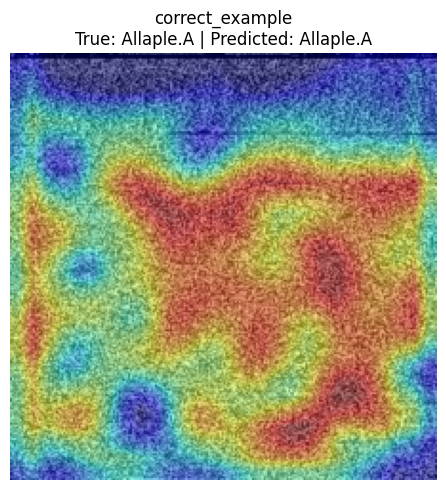

  0%|          | 0/1000 [00:00<?, ?it/s]

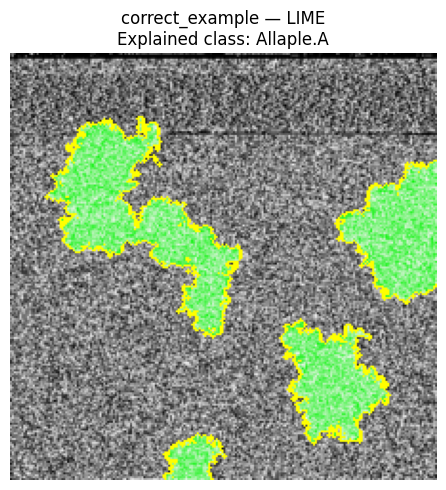


wrong_example
File: /kaggle/input/datasets/ikrambenabd/malimg-original/malimg_paper_dataset_imgs/Rbot!gen/1c019b59a436aa910ab885d3fabfe50f.exe.png
True: Rbot!gen
Predicted: Autorun.K


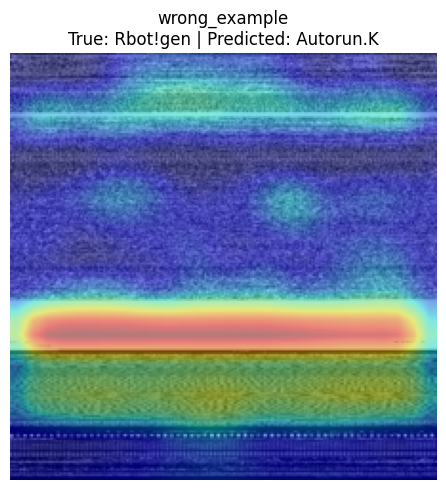

  0%|          | 0/1000 [00:00<?, ?it/s]

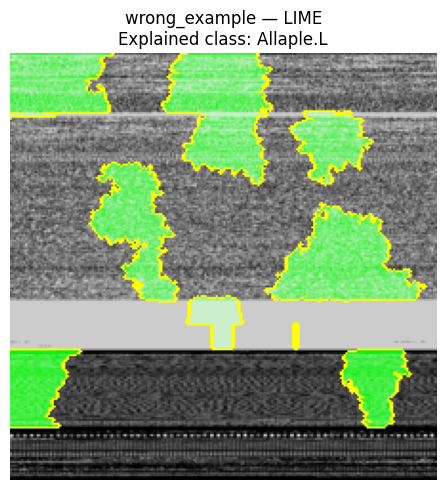

In [35]:

# ============================================================
# RUN EXPLAINABILITY ON ONE CORRECT + ONE WRONG SAMPLE
# ============================================================

if RUN_EXPLAINABILITY and final_model is not None:
    correct_rows = final_predictions_df[
        final_predictions_df["correct"] == True
    ]
    wrong_rows = final_predictions_df[
        final_predictions_df["correct"] == False
    ]

    selected = []

    if len(correct_rows):
        selected.append(
            ("correct_example", correct_rows.iloc[0])
        )

    if len(wrong_rows):
        selected.append(
            ("wrong_example", wrong_rows.iloc[0])
        )

    for sample_title, row in selected:
        print("\n" + "=" * 88)
        print(sample_title)
        print("=" * 88)
        print("File:", row["filepath"])
        print("True:", row["true_family"])
        print("Predicted:", row["predicted_family"])

        true_id = int(row["true_label"])
        pred_id = int(row["predicted_label"])

        show_gradcam(
            final_model,
            row["filepath"],
            true_id,
            pred_id,
            sample_title
        )

        run_lime_explanation(
            final_model,
            row["filepath"],
            sample_title
        )
else:
    print("RUN_EXPLAINABILITY=False or final model unavailable.")


## Report-ready interpretation template

After the experiments finish, use the saved tables to fill the following conclusions with actual values:

1. **Attention:** CBAM vs no-attention should be interpreted using Macro-F1 and Macro Recall, not accuracy alone.
2. **Best configuration:** selected by validation Macro-F1.
3. **CV:** report `mean ± std` for Macro-F1 and supporting metrics.
4. **Significance:** report Wilcoxon statistic and p-value against EfficientNetB0.
5. **Explainability:** describe Grad-CAM/LIME as discriminative regions; avoid claiming they prove specific malware semantics.
6. **Final comparison:** compare the official Task 2 best baseline, Task 2 first model, and Task 3 final model on the untouched test set.


In [36]:

# ============================================================
# FINAL TASK 3 ARTIFACT INVENTORY
# ============================================================

print("=" * 88)
print("TASK 3 OUTPUT INVENTORY")
print("=" * 88)

for p in sorted(OUTPUT_DIR.rglob("*")):
    if p.is_file():
        print("-", p.relative_to(OUTPUT_DIR))

print("\nTask 3 notebook workflow complete.")
print("Primary metric:", PRIMARY_METRIC)
print("Test set used for tuning:", "NO")


TASK 3 OUTPUT INVENTORY
- best_baseline_5fold_cv.csv
- explainability/correct_example_gradcam.png
- explainability/correct_example_lime.png
- explainability/wrong_example_gradcam.png
- explainability/wrong_example_lime.png
- final_model_5fold_cv.csv
- final_model_comparison.csv
- final_selected_config.json
- final_test/Task3_FinalModel/Task3_FinalModel.keras
- final_test/Task3_FinalModel/Task3_FinalModel_classification_report.csv
- final_test/Task3_FinalModel/Task3_FinalModel_confusion_matrix.csv
- final_test/Task3_FinalModel/Task3_FinalModel_metrics.json
- final_test/Task3_FinalModel/Task3_FinalModel_test_predictions.csv
- final_test/Task3_FinalModel_best.keras
- task3_ablation_results.csv
- task3_cv_summary.csv
- task3_tuning_results.csv
- tuning/ablation_cbam/history.csv
- tuning/ablation_cbam/validation_result.json
- tuning/ablation_channel/history.csv
- tuning/ablation_channel/validation_result.json
- tuning/ablation_cnn/history.csv
- tuning/ablation_cnn/validation_result.json
- t